In [1]:
import data

import typing as tt
import pathlib
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split, Dataset

import matplotlib.pylab as plt

In [2]:
class Network(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.Linear(500, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x).squeeze()

In [3]:
TRAIN_PATH = pathlib.Path("data_v1.feather")
BATCH_CHUNKS = 2

In [4]:
torch.manual_seed(12)

In [5]:
dataset = data.FeatherChunksDataset(TRAIN_PATH)
train_dataset, val_dataset, test_dataset = \
    random_split(dataset, [0.8, 0.1, 0.1])

In [6]:
model = Network(len(dataset.columns))

In [7]:
device = torch.device("cpu")
weights_dict = torch.load("v1_best.model", map_location=device, 
                          weights_only=True)
model.load_state_dict(weights_dict)

<All keys matched successfully>

In [8]:
@torch.no_grad()
def validate(model: Network, dataset: data.Dataset) -> float:
    loader = DataLoader(dataset, BATCH_CHUNKS, shuffle=False,
                        collate_fn=data.collate_batches)
    loss = nn.MSELoss()
    losses = []
    for batch_x, batch_y in loader:
        out_t = model(batch_x)
        loss_t = loss(out_t, batch_y)
        losses.append(np.sqrt(loss_t.detach().item()))
    return np.mean(losses)

In [9]:
for ds in (train_dataset, val_dataset, test_dataset):
    loss = validate(model, ds)
    print(loss)

3.2584023117432612
3.3257916077975858
3.3249516103458383


In [10]:
s, c = 0.0, 0
for _, y in dataset:
    s += torch.mean(y)
    c += 1
print(f"Average fare: ${s/c:.5f}")

Average fare: $11.31369


In [11]:
tgt, pred = [], []
with torch.no_grad():
    for idx, (batch_x, batch_y) in enumerate(val_dataset):
        if idx > 200:
            break
        out_t = model(batch_x)
        tgt.append(batch_y.numpy())
        pred.append(out_t.numpy())
tgt = np.concatenate(tgt)
pred = np.concatenate(pred)
res = tgt - pred
print("Min", np.min(res), "max", np.max(res))
print("Mean", np.mean(res), "std", np.std(res))
print("Fare with minimum error", res[np.argmin(res)])
print("Fare with maximum error", res[np.argmax(res)])

Min -116.201546 max 171.83891
Mean -0.04488529 std 3.3397574
Fare with minimum error -116.201546
Fare with maximum error 171.83891


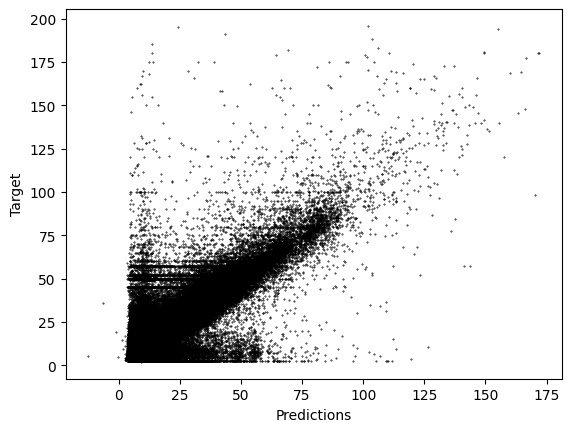

In [12]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(pred, tgt, '.', color='black', markersize=.8);
ax.set_xlabel("Predictions")
ax.set_ylabel("Target");

In [13]:
#fig.savefig("model-check.png", dpi=300)